# 🔬 BioSLATE Phase 2B — Synthetic Lethal Target Discovery (HGSOC)

**Author:** Faith Ogundimu  
**Date:** July 24th 2025

__Notebook Purpose__
To identify context-specific synthetic lethal (SL) dependencies in HGSOC cell lines using DepMap CRISPR data.

__Methods Tried__
- **Welch’s t-test**: initial method to compare gene dependency between biomarker-positive vs wild-type lines. (see deprecated_sl_screen.ipynb)
- **OLS Linear Regression**: final method, modelling gene dependency as a function of biomarker CNA status, with effect size estimated from predicted dependency at CNA=2 vs CNA=6.

__Config Highlights__
- Biomarkers: CNA-amplified genes validated in both TCGA and DepMap.
- Clustering: Biomarkers with identical CNA profiles grouped into clusters.
- Representative gene per cluster selected via **CrewAI agent**, ranked by SL/cancer relevance and druggability (see agents/cluster_selector_agent.py).
- **Manual override** applied for key oncogenes (e.g. CCNE1, KRAS, MYC, MECOM) to ensure biological plausibility.

__Output Per Pair__
- FDR, effect size (Δ CNA6 vs CNA2), regression stats
- Filters for context-specificity (≥6 lines, target not essential in WT)

## Step 1: Load Files and Process as Necessary Screening Configurations

In [3]:
# Required packages
import pandas as pd
import numpy as np

# Load input datasets:
## AMP biomarkers
amp_biomarkers = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cross_val_amp_sig_genes.csv", index_col=1)
amp_biomarkers = amp_biomarkers.index.astype(str)
amp_biomarkers

## CNA DepMap for AMP screen
cna_hgsoc_depmap = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cna_depmap_hgsoc.csv", index_col=0)
cna_hgsoc_depmap = cna_hgsoc_depmap.transpose()
cna_hgsoc_depmap_filtered_amp = cna_hgsoc_depmap.loc[amp_biomarkers]
cna_hgsoc_depmap_filtered_amp = cna_hgsoc_depmap_filtered_amp.transpose()

## CRISPR
crispr_filtered = pd.read_csv("../results/crispr_hgsoc.csv", index_col=0) 

In [19]:
cna_hgsoc_depmap_filtered_amp

Gene,10016,1004,10051,10054,10059,10139,10195,10298,10397,10404,...,9601,96764,9684,9718,9757,9777,9791,9846,9847,9885
ACH-000132,3.0,3.0,7.0,4.0,4.0,7.0,6.0,4.000000,4.000000,4.0,...,3.0,4.00000,8.000000,6.0,4.0,3.000000,4.0,6.000000,6.0,7.0
ACH-002183,2.0,2.0,3.0,2.0,2.0,3.0,3.0,2.000000,2.000000,2.0,...,2.0,5.00000,5.000000,3.0,2.0,2.000000,2.0,2.000000,2.0,4.0
ACH-001151,3.0,2.0,4.0,2.0,2.0,3.0,4.0,2.000000,4.000000,4.0,...,2.0,4.00000,4.000000,4.0,2.0,3.000000,4.0,3.000000,2.0,3.0
ACH-000635,6.0,3.0,4.0,4.0,3.0,3.0,6.0,5.000000,11.862681,3.0,...,4.0,3.00000,12.982926,6.0,5.0,3.000000,6.0,5.000000,3.0,3.0
ACH-000430,3.0,3.0,3.0,2.0,2.0,3.0,3.0,2.000000,3.000000,3.0,...,4.0,3.00000,3.000000,3.0,2.0,3.000000,3.0,3.000000,2.0,3.0
ACH-002140,4.0,4.0,6.0,4.0,6.0,5.0,6.0,4.000000,7.000000,7.0,...,1.0,7.00000,7.000000,6.0,4.0,5.000000,7.0,4.000000,6.0,5.0
ACH-000103,6.0,4.0,3.0,4.0,3.0,6.0,3.0,4.000000,2.000000,2.0,...,3.0,2.00000,2.000000,3.0,4.0,4.000000,2.0,2.000000,3.0,6.0
ACH-000001,4.0,4.0,7.0,6.0,5.0,6.0,5.0,12.711317,4.000000,4.0,...,3.0,5.00000,4.000000,5.0,6.0,5.000000,4.0,13.413596,7.0,6.0
ACH-000256,4.0,4.0,5.0,7.0,4.0,7.0,4.0,2.000000,2.000000,2.0,...,6.0,3.00000,2.000000,4.0,7.0,8.000000,2.0,5.000000,3.0,7.0
ACH-000542,5.0,5.0,7.0,4.0,6.0,6.0,6.0,4.000000,8.000000,8.0,...,2.0,8.00000,8.000000,6.0,4.0,6.000000,8.0,5.000000,6.0,6.0


In [2]:
amp_biomarkers

Index(['10016', '1004', '10051', '10054', '10059', '10139', '10195', '10298',
       '10397', '10404',
       ...
       '9601', '96764', '9684', '9718', '9757', '9777', '9791', '9846', '9847',
       '9885'],
      dtype='object', name='Gene', length=325)

## Step 2: Handling Potential Co-Amplification Confounding

To avoid false positives from genes that are co-amplified together across cell lines:

* **Exact CNA profile clustering** is used:

  * Genes with *identical* CNA values across all profiled cell lines are grouped into a cluster.
  * Only one gene (the first) is retained as the representative biomarker per cluster.
  * This avoids redundancy when multiple genes share indistinguishable CNA patterns.

* This is a strict filter — it **does not** capture biologically co-amplified genes unless their profiles are identical.

* For broader co-amplification handling:

  * Consider computing **pairwise CNA correlations** across biomarkers.
  * Filter or annotate hits where biomarker–target pairs are frequently **co-amplified** in the same cell lines.

This step helps reduce artificial hits due to shared amplification patterns rather than genuine synthetic lethality.


In [24]:
## AMPS - CNA
configs = [
    {"name": "CNA_quantitative_cluster_delta"}
]

In [3]:
## AMP

import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from collections import defaultdict

def run_sl_screen(config, amp_biomarkers, cna_df, crispr_df, out_root="../results"):
    name = config["name"]

    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "other"), exist_ok=True)

    # Use continuous CNA directly
    status_df = cna_df[amp_biomarkers.intersection(cna_df.columns)]

    # Cluster biomarkers with identical CNA profiles
    profile_groups = defaultdict(list)
    for gene in status_df.columns:
        profile = tuple(status_df[gene].fillna("NA").values)
        profile_groups[profile].append(gene)
    biomarker_sets = [(group[0], ", ".join(sorted(group))) for group in profile_groups.values()]

    results = []
    for rep_gene, cluster_str in biomarker_sets:
        if rep_gene not in cna_df.columns:
            continue

        cna_vector = cna_df[rep_gene].dropna()
        common_lines = cna_vector.index.intersection(crispr_df.index)

        if len(common_lines) < 6:
            continue

        cna_vector = cna_vector.loc[common_lines]

        for target in crispr_df.columns:
            dep_vector = crispr_df[target].loc[common_lines].dropna()
            matched = dep_vector.index.intersection(cna_vector.index)

            if len(matched) < 6:
                continue

            # Require at least one strongly dependent cell line
            if not (dep_vector.loc[matched] < -0.6).any():
                continue

            X = sm.add_constant(cna_vector.loc[matched])
            y = dep_vector.loc[matched]

            try:
                model = sm.OLS(y, X).fit(cov_type="HC3")
                beta = model.params.iloc[1]
                p_val = model.pvalues.iloc[1]
                t_stat = model.tvalues.iloc[1]
                conf_int = model.conf_int().iloc[1]
                effect_size = beta / y.std(ddof=1) if y.std(ddof=1) > 0 else np.nan
                predicted_at_cna2 = model.predict([1, 2])[0]

                # Mean effect in samples where CNA ≥ 6
                high_amp_lines = cna_vector[cna_vector >= 6].index
                mean_effect_amp6plus = y.loc[high_amp_lines].mean() if not y.loc[high_amp_lines].empty else np.nan

                delta = mean_effect_amp6plus - predicted_at_cna2 if pd.notnull(mean_effect_amp6plus) else np.nan
            except:
                continue

            results.append({
                "Biomarker": rep_gene,
                "BiomarkerCluster": cluster_str,
                "TargetGene": target,
                "OncogeneAddiction": rep_gene == target,
                "Beta": beta,
                "T-stat": t_stat,
                "P-value": p_val,
                "EffectSize": effect_size,
                "CI_Lower": conf_int[0],
                "CI_Upper": conf_int[1],
                "n_Lines": len(matched),
                "MeanCNA": cna_vector.loc[matched].mean(),
                "MeanEffect": y.mean(),
                "MeanEffect_CNA6plus": mean_effect_amp6plus,
                "PredictedEffect_CNA2": predicted_at_cna2,
                "DeltaEffect_CNA6minusPred2": delta
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df["FDR"] = multipletests(results_df["P-value"], method="fdr_bh")[1]
    else:
        results_df["FDR"] = []

    results_df.to_csv(f"{out_dir}/synthetic_lethality_screen.csv", index=False)

    pval_hits = results_df[results_df["P-value"] < 0.05]
    pval_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_pval.csv", index=False)

    fdr_hits = results_df[results_df["FDR"] < 0.05]
    fdr_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_fdr.csv", index=False)

    strong_hits = fdr_hits[fdr_hits["EffectSize"] < 0]
    strong_hits.to_csv(f"{out_dir}/strong_synthetic_lethal_hits.csv", index=False)

    selective_hits = strong_hits[strong_hits["PredictedEffect_CNA2"] > -1]
    selective_hits.to_csv(f"{out_dir}/selective_synthetic_lethal_hits.csv", index=False)

    return {
        "ConfigName": name,
        "SLTests": len(results_df),
        "FDRHits": len(fdr_hits),
        "StrongHits": len(strong_hits),
        "SelectiveHits": len(selective_hits)
    }

In [14]:
## AMPS - Expression
configs = [
    {"name": "EXPR_CNA_quantitative_cluster_delta"}
]

## Step 2: Initial Expression-Based Validation Screen

To test whether synthetic lethal relationships identified through CNA analysis replicate at the transcriptional level:

* **Quantile-based expression grouping** is used:
  
  * "High expression" samples defined as those above the 80th percentile for each biomarker
  * "Baseline expression" samples defined as those around the median (50th percentile)  
  * Linear regression models dependency as a function of continuous expression values

* **Independent sample selection**:
  
  * Expression groups are defined purely by transcript abundance levels
  * No constraint that high-expression samples correspond to CNA-amplified samples
  * This tests whether elevated gene expression (regardless of mechanism) drives synthetic lethality

* **Statistical approach**:
  
  * Same OLS regression framework as CNA analysis: `Dependency ~ Expression_value`
  * Effect sizes calculated as difference between high-expression and median-expression predicted values
  * Multiple testing correction applied using Benjamini-Hochberg FDR

* **Validation logic**:
  
  * Synthetic lethal pairs significant in both CNA and expression screens considered "validated"
  * Low overlap rates initially observed, suggesting different biological signals captured by each approach


In [15]:
## EXPR

import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from collections import defaultdict

def run_sl_screen_expression(config, biomarkers, expr_df, crispr_df, out_root="../results"):
    name = config["name"]

    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "other"), exist_ok=True)

    status_df = expr_df[biomarkers.intersection(expr_df.columns)]

    results = []
    for rep_gene in status_df.columns:
        expr_vector = expr_df[rep_gene].dropna()
        common_lines = expr_vector.index.intersection(crispr_df.index)

        if len(common_lines) < 6:
            continue

        expr_vector = expr_vector.loc[common_lines]

        # Define high and baseline groups
        high_thresh = expr_vector.quantile(0.8)
        low_thresh = expr_vector.quantile(0.5)  # median for predicted baseline
        high_lines = expr_vector[expr_vector >= high_thresh].index

        for target in crispr_df.columns:
            dep_vector = crispr_df[target].loc[common_lines].dropna()
            matched = dep_vector.index.intersection(expr_vector.index)

            if len(matched) < 6:
                continue

            if not (dep_vector.loc[matched] < -0.6).any():
                continue

            X = sm.add_constant(expr_vector.loc[matched])
            y = dep_vector.loc[matched]

            try:
                model = sm.OLS(y, X).fit(cov_type="HC3")
                beta = model.params.iloc[1]
                p_val = model.pvalues.iloc[1]
                t_stat = model.tvalues.iloc[1]
                conf_int = model.conf_int().iloc[1]
                effect_size = beta / y.std(ddof=1) if y.std(ddof=1) > 0 else np.nan
                predicted_at_median = model.predict([1, low_thresh])[0]

                # Mean effect in high expression lines
                mean_effect_high = y.loc[high_lines].mean() if not y.loc[high_lines].empty else np.nan
                delta = mean_effect_high - predicted_at_median if pd.notnull(mean_effect_high) else np.nan
            except:
                continue

            results.append({
                "Biomarker": rep_gene,
                "TargetGene": target,
                "OncogeneAddiction": rep_gene == target,
                "Beta": beta,
                "T-stat": t_stat,
                "P-value": p_val,
                "EffectSize": effect_size,
                "CI_Lower": conf_int[0],
                "CI_Upper": conf_int[1],
                "n_Lines": len(matched),
                "MeanExpr": expr_vector.loc[matched].mean(),
                "MeanEffect": y.mean(),
                "MeanEffect_HighExpr": mean_effect_high,
                "PredictedEffect_MedianExpr": predicted_at_median,
                "DeltaEffect_HighMinusMedian": delta
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df["FDR"] = multipletests(results_df["P-value"], method="fdr_bh")[1]

    results_df.to_csv(f"{out_dir}/synthetic_lethality_screen.csv", index=False)

    pval_hits = results_df[results_df["P-value"] < 0.05]
    pval_hits.to_csv(f"{out_dir}/other/significant_hits_pval.csv", index=False)

    fdr_hits = results_df[results_df["FDR"] < 0.05]
    fdr_hits.to_csv(f"{out_dir}/other/significant_hits_fdr.csv", index=False)

    strong_hits = fdr_hits[fdr_hits["EffectSize"] < 0]
    strong_hits.to_csv(f"{out_dir}/strong_hits.csv", index=False)

    selective_hits = strong_hits[strong_hits["PredictedEffect_MedianExpr"] > -1]
    selective_hits.to_csv(f"{out_dir}/selective_hits.csv", index=False)

    return {
        "ConfigName": name,
        "SLTests": len(results_df),
        "FDRHits": len(fdr_hits),
        "StrongHits": len(strong_hits),
        "SelectiveHits": len(selective_hits)
    }

## Step 3: Run All Configurations and Collect Summary Stats

This loop:
- Runs `run_sl_screen()` for each config in the list
- Prints which config is currently running
- Stores the summary stats (e.g. number of SL tests, FDR hits, etc.)
- Outputs a `summary_df` DataFrame showing comparative results
- Saves the summary to a CSV for downstream reporting

Expect each config to take a few seconds to run depending on your biomarker and CRISPR data size.

In [4]:
## AMP
summary = []

for cfg in configs:
    print(f"Running config: {cfg['name']}")
    result = run_sl_screen(cfg, amp_biomarkers, cna_hgsoc_depmap_filtered_amp, crispr_filtered)
    summary.append(result)

summary_df = pd.DataFrame(summary)
summary_df

Running config: AMP_CNA_quantitative_cluster_delta


,ConfigName,SLTests,FDRHits,StrongHits,SelectiveHits
0,AMP_CNA_quantitative_cluster_delta,790485,4269,1930,1282


In [16]:
## EXPR
summary = []

for cfg in configs:
    print(f"Running config: {cfg['name']}")
    result = run_sl_screen_expression(cfg, amp_biomarkers, expr_df_filtered_amp, crispr_filtered)
    summary.append(result)

summary_df = pd.DataFrame(summary)
summary_df

Running config: EXPR_CNA_quantitative_cluster_delta


,ConfigName,SLTests,FDRHits,StrongHits,SelectiveHits
0,EXPR_CNA_quantitative_cluster_delta,898254,5885,3192,2067


### Assess Overlap

In [18]:
import pandas as pd

cna_csv   = "../results/CNA_quantitative_cluster_delta/selective_synthetic_lethal_hits.csv"
expr_csv  = "../results/EXPR_CNA_quantitative_cluster_delta/selective_hits.csv"

# --- load ---
cna = pd.read_csv(cna_csv)
expr = pd.read_csv(expr_csv)

# --- normalise identifiers (defensive) ---
def norm(s):
    return s.astype(str).str.strip().str.upper()

for df in (cna, expr):
    df["Biomarker"] = norm(df["Biomarker"])
    df["TargetGene"] = norm(df["TargetGene"])

# --- define pair keys ---
cna["pair"]  = list(zip(cna["Biomarker"], cna["TargetGene"]))
expr["pair"] = list(zip(expr["Biomarker"], expr["TargetGene"]))

set_cna  = set(cna["pair"])
set_expr = set(expr["pair"])

# --- core stats ---
n_cna   = len(set_cna)
n_expr  = len(set_expr)
n_inter = len(set_cna & set_expr)
n_union = len(set_cna | set_expr)

pct_expr_in_cna = 100.0 * n_inter / n_expr if n_expr else 0.0   # “coverage” of expr by cna
pct_cna_in_expr = 100.0 * n_inter / n_cna if n_cna else 0.0     # “coverage” of cna by expr
jaccard         = n_inter / n_union if n_union else 0.0

print(f"CNA selective pairs: {n_cna}")
print(f"EXPR selective pairs: {n_expr}")
print(f"Intersection: {n_inter}")
print(f"Union: {n_union}")
print(f"% of EXPR pairs also in CNA: {pct_expr_in_cna:.1f}%")
print(f"% of CNA pairs also in EXPR: {pct_cna_in_expr:.1f}%")
print(f"Jaccard index (pair-level): {jaccard:.3f}")

# --- overlaps to inspect ---
overlap_pairs = pd.DataFrame(list(set_cna & set_expr), columns=["Biomarker","TargetGene"])
overlap_pairs.to_csv("../results/overlap_pairs_cna_expr.csv", index=False)

# Optional: where does overlap concentrate? (top biomarkers and targets)
overlap_by_biomarker = overlap_pairs["Biomarker"].value_counts().head(20)
overlap_by_target    = overlap_pairs["TargetGene"].value_counts().head(20)
print("\nTop biomarkers in the overlap:\n", overlap_by_biomarker)
print("\nTop targets in the overlap:\n", overlap_by_target)

# --- target-only overlap, ignoring biomarker ---
cna_targets  = set(norm(cna["TargetGene"]))
expr_targets = set(norm(expr["TargetGene"]))
t_inter = len(cna_targets & expr_targets)
t_union = len(cna_targets | expr_targets)
print("\nTarget-only overlap (ignoring biomarker):")
print(f"  CNA targets: {len(cna_targets)} | EXPR targets: {len(expr_targets)} | Intersection: {t_inter}")
print(f"  % of EXPR targets also in CNA: {100*t_inter/len(expr_targets):.1f}%" if expr_targets else "  n/a")
print(f"  % of CNA targets also in EXPR: {100*t_inter/len(cna_targets):.1f}%" if cna_targets else "  n/a")
print(f"  Jaccard (targets): {t_inter/t_union:.3f}" if t_union else "  n/a")

# --- per-biomarker overlap rates ---
#   For each biomarker present in either run, what fraction of its targets overlap?
all_biomarkers = sorted(set(cna["Biomarker"]) | set(expr["Biomarker"]))
rows = []
for b in all_biomarkers:
    cna_t = set(cna.loc[cna["Biomarker"] == b, "TargetGene"])
    expr_t = set(expr.loc[expr["Biomarker"] == b, "TargetGene"])
    inter = cna_t & expr_t
    if len(cna_t) or len(expr_t):
        rows.append({
            "Biomarker": b,
            "CNA_targets": len(cna_t),
            "EXPR_targets": len(expr_t),
            "Intersection": len(inter),
            "%EXPR_in_CNA": 100*len(inter)/len(expr_t) if expr_t else 0.0,
            "%CNA_in_EXPR": 100*len(inter)/len(cna_t) if cna_t else 0.0,
            "Jaccard": len(inter)/len(cna_t | expr_t) if (cna_t | expr_t) else 0.0
        })
per_biomarker_overlap = pd.DataFrame(rows).sort_values("Jaccard", ascending=False)
per_biomarker_overlap.to_csv("../results/per_biomarker_overlap_cna_expr.csv", index=False)


CNA selective pairs: 1075
EXPR selective pairs: 2067
Intersection: 99
Union: 3043
% of EXPR pairs also in CNA: 4.8%
% of CNA pairs also in EXPR: 9.2%
Jaccard index (pair-level): 0.033

Top biomarkers in the overlap:
 Biomarker
28971     18
283219    16
1207      15
51773      9
8725       7
23012      5
23509      3
23126      3
126526     3
163882     3
7328       2
2271       2
4067       2
92609      2
10526      1
55500      1
1537       1
79718      1
64754      1
55095      1
Name: count, dtype: int64

Top targets in the overlap:
 TargetGene
617       4
23293     3
147965    3
8233      3
10370     3
253260    3
286053    3
163131    3
51244     2
279       2
22992     2
114823    2
6598      2
55355     2
64745     2
114034    2
51755     2
65260     2
6901      2
10463     2
Name: count, dtype: int64

Target-only overlap (ignoring biomarker):
  CNA targets: 337 | EXPR targets: 762 | Intersection: 192
  % of EXPR targets also in CNA: 25.2%
  % of CNA targets also in EXPR: 57.0%


## Filter to Most Potent Hits

In [7]:
selective_hits_amp = pd.read_csv("../results/CNA_quantitative_cluster_delta/selective_synthetic_lethal_hits.csv")

potent_hits_amp = selective_hits_amp[
    (selective_hits_amp["DeltaEffect_CNA6minusPred2"] <= -0.7) &
    (selective_hits_amp["PredictedEffect_CNA2"] >= -0.6)
]

potent_hits_amp.to_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits.csv", index=False)

len(potent_hits_amp)

74

## Step 4: Add HGNC Gene Symbols to SL Results

This step maps Entrez Gene IDs in the `Biomarker` and `TargetGene` columns to their official HGNC gene symbols using the `gene_with_protein_product.txt` reference file.

The HGNC names are inserted directly beside each ID column in both:
- `strong_synthetic_lethal_hits.csv`
- `selective_synthetic_lethal_hits.csv`

Updated files are saved with `_with_HGNC` suffix in the `../results/` folder.


In [8]:
import pandas as pd

# Load your result files
sl_hits_potent_amp = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits.csv")
# sl_hits_potent_del = pd.read_csv("../results/DEL_CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(
        loc=df.columns.get_loc("Biomarker") + 1,
        column="Biomarker_HGNC",
        value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x)))
    )

    df.insert(
        loc=df.columns.get_loc("TargetGene") + 1,
        column="TargetGene_HGNC",
        value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x)))
    )

    df.insert(
        loc=df.columns.get_loc("BiomarkerCluster") + 1,
        column="BiomarkerCluster_HGNC",
        value=df["BiomarkerCluster"].apply(
            lambda cluster: ", ".join([
                entrez_to_symbol.get(gid.strip(), "NA")
                for gid in cluster.split(",")
            ])
        )
    )
    return df

# Apply to DataFrame
sl_hits_potent_amp = insert_hgnc_columns(sl_hits_potent_amp)
# sl_hits_potent_del = insert_hgnc_columns(sl_hits_potent_del)

# Save updated files
sl_hits_potent_amp.to_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv", index=False)
# sl_hits_potent_del.to_csv("../results/DEL_CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv", index=False)

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_94053/577477492.py:8: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


## Clean Hits for Agent

In [26]:
import pandas as pd

# Load your full potent hits file
input_file = "../results/AMP_CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv"
df = pd.read_csv(input_file)

# Extract required columns for the agent
agent_input_df = df[["BiomarkerCluster_HGNC", "TargetGene_HGNC"]].copy()

# Save for agent use
output_file = "../agents/assets/cluster_hits_amps.csv"
agent_input_df.to_csv(output_file, index=False)

print(f"Cleaned agent input saved to: {output_file}")

Cleaned agent input saved to: ../agents/assets/cluster_hits_amps.csv


### Altering Representative Biomarker based on Agent
Only after agent has run

In [32]:
import pandas as pd

# Load files
sl_hits = pd.read_csv("../results/AMP_CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv")
reps = pd.read_csv("../agents/cluster_selector/representative_biomarkers.csv")

# Map: cluster → representative gene
cluster_to_rep = dict(zip(reps["BiomarkerCluster_HGNC"], reps["ClusterRepresentative"]))

# Replace biomarker with representative
sl_hits["Biomarker_HGNC"] = sl_hits["BiomarkerCluster_HGNC"].map(cluster_to_rep)

# Save
sl_hits.to_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv", index=False)

## Step 5: Visualising Regression-Based Synthetic Lethality Hits

This section presents key visualisations to interpret the output of the SL regression screen.

- **Volcano Plot**: Displays the global landscape of biomarker–target interactions by effect size and statistical confidence.
- **Regression Scatterplots**: Show model fit for individual top hits, illustrating the relationship between biomarker CNA and target dependency.
- **Heatmap**: Summarises gene effect scores of selected SL targets across HGSOC cell lines, highlighting context-specific vulnerabilities.

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_94053/961504135.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")


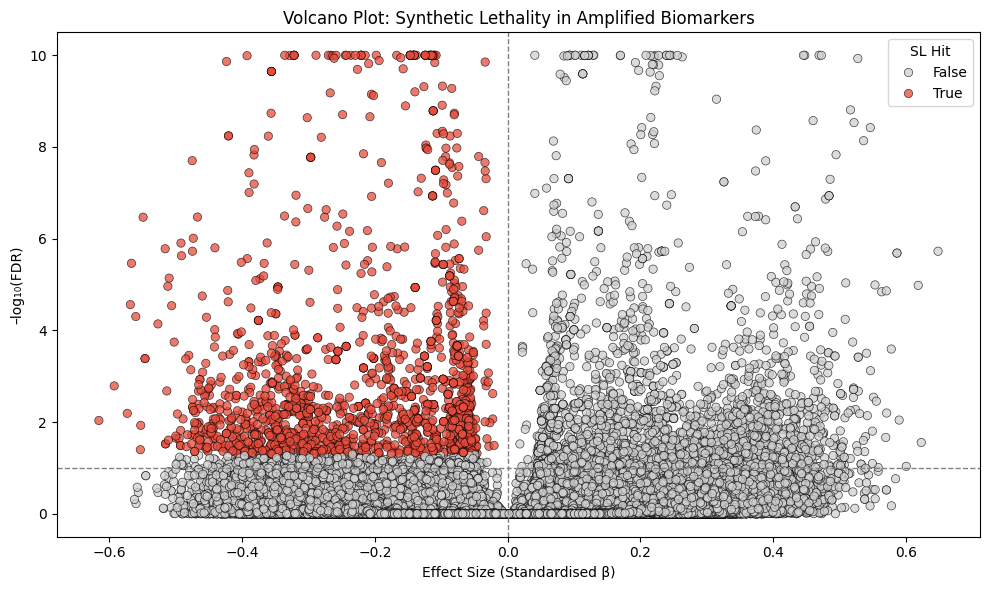

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load hits
df = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")

# Add -log10(FDR) and SL hit status
df["–log10(FDR)"] = -np.log10(df["FDR"] + 1e-10)  # avoid log(0)
df["SL_Hit"] = (df["EffectSize"] < 0) & (df["FDR"] < 0.05)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="EffectSize",
    y="–log10(FDR)",
    hue="SL_Hit",
    palette={True: "#e74c3c", False: "#d0d0d0"},
    alpha=0.75,
    edgecolor="black"
)

plt.axhline(y=-np.log10(0.1), linestyle="--", color="gray", linewidth=1)
plt.axvline(x=0, linestyle="--", color="gray", linewidth=1)
plt.xlabel("Effect Size (Standardised β)")
plt.ylabel("–log₁₀(FDR)")
plt.title("Volcano Plot: Synthetic Lethality in Amplified Biomarkers")
plt.legend(title="SL Hit", loc="upper right")
plt.tight_layout()
plt.show()

In [28]:
### add hgnc column to complete synthetic lethal screen csv

import pandas as pd

# Load your result files
sl_screen = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(loc=df.columns.get_loc("Biomarker") + 1,
              column="Biomarker_HGNC",
              value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x))))
    
    df.insert(loc=df.columns.get_loc("TargetGene") + 1,
              column="TargetGene_HGNC",
              value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x))))
    return df

# Apply to both DataFrames
sl_screen = insert_hgnc_columns(sl_screen)

# Save updated files
sl_screen.to_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen_with_HGNC.csv", index=False)


/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/390793496.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sl_screen = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")
/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/390793496.py:9: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


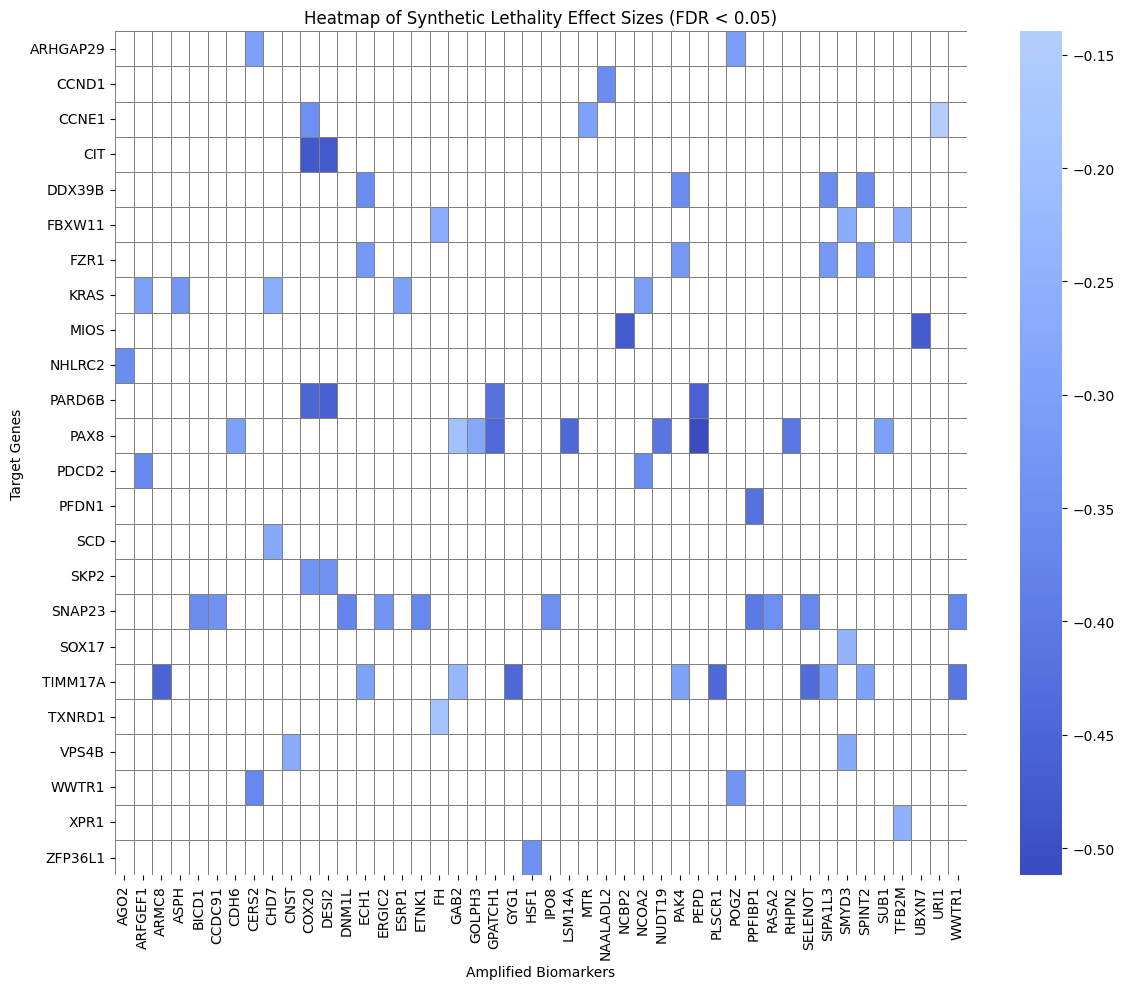

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
results_df = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv")

# Pivot: rows = target genes, cols = biomarkers, values = Effect Size
heatmap_df = results_df.pivot(index="TargetGene_HGNC", columns="Biomarker_HGNC", values="EffectSize")

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, cmap="coolwarm", center=0, linewidths=0.5, linecolor="gray")
plt.title("Heatmap of Synthetic Lethality Effect Sizes (FDR < 0.05)")
plt.xlabel("Amplified Biomarkers")
plt.ylabel("Target Genes")
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

# Set up plotting style
sns.set(style="whitegrid", context="notebook")
os.makedirs("../figures/sl_plots", exist_ok=True)

# Load matrices
cna_df = pd.read_csv("../results/cna_depmap_hgsoc.csv", index_col=0)
crispr_df = pd.read_csv("../results/crispr_hgsoc.csv", index_col=0)
cna_df.columns = cna_df.columns.astype(str)
crispr_df.columns = crispr_df.columns.astype(str)

# Load hits
df = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv")
df["Biomarker"] = df["Biomarker"].astype(str)
df["TargetGene"] = df["TargetGene"].astype(str)

# Load HGNC mapping file (Entrez → HGNC)
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t", dtype=str)
entrez_to_hgnc = dict(zip(hgnc_df["entrez_id"], hgnc_df["symbol"]))

# Plot
for idx, row in df[["Biomarker", "TargetGene"]].dropna().iterrows():
    biomarker = row["Biomarker"]
    target = row["TargetGene"]

    if biomarker not in cna_df.columns or target not in crispr_df.columns:
        print(f"Skipping {biomarker}–{target}: not found in matrix")
        continue

    x = cna_df[biomarker].dropna()
    y = crispr_df[target].dropna()
    common = x.index.intersection(y.index)

    if len(common) < 3:
        print(f"Skipping {biomarker}–{target}: not enough overlapping lines")
        continue

    r, p = pearsonr(x[common], y[common])

    # Map Entrez to HGNC for display (fallback to Entrez if missing)
    biomarker_label = entrez_to_hgnc.get(biomarker, biomarker)
    target_label = entrez_to_hgnc.get(target, target)

    plt.figure(figsize=(6, 4))
    sns.regplot(x=x[common], y=y[common],
                scatter_kws={"s": 50, "alpha": 0.8},
                line_kws={"color": "black", "linewidth": 1})

    plt.xlabel(f"{biomarker_label} CNA", fontsize=10)
    plt.ylabel(f"{target_label} Dependency Score", fontsize=10)
    plt.title(f"{biomarker_label} vs {target_label} Dependency\nr = {r:.2f}, p = {p:.4f}", fontsize=11)
    plt.tight_layout()

    # Save using HGNC names for readability (fallbacks handled)
    safe_name = f"{biomarker_label}_{target_label}".replace("/", "_")
    plt.savefig(f"../figures/sl_plots/{safe_name}_regression.png", dpi=300)
    plt.close()

### Getting Chromosomes for Hits

In [1]:
import sys
import subprocess

# Install the gprofiler-official package if it's not already installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "mygene"])

  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
  Using cached biothings_client-0.4.1-py3-none-any.whl.metadata (10 kB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)
Using cached biothings_client-0.4.1-py3-none-any.whl (46 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip3.10 install --upgrade pip


0

In [12]:
import pandas as pd
from mygene import MyGeneInfo

# Load your file
df = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv") 

# Extract first gene symbol from comma-separated lists
df["Biomarker_HGNC_first"] = df["Biomarker_HGNC"].str.split(",").str[0].str.strip()
df["TargetGene_HGNC_first"] = df["TargetGene_HGNC"].str.split(",").str[0].str.strip()

# Collect unique gene names to query
genes_to_query = pd.unique(df[["Biomarker_HGNC_first", "TargetGene_HGNC_first"]].values.ravel())

# Query MyGene.info for chromosome info
mg = MyGeneInfo()
query_results = mg.querymany(genes_to_query, scopes="symbol", fields="map_location", species="human", as_dataframe=True)

# Extract and clean chromosome info
chrom_df = query_results.reset_index()[["query", "map_location"]].dropna().drop_duplicates()
chrom_df["Chromosome"] = chrom_df["map_location"].str.extract(r"^(\d+|X|Y)")
chrom_df["Chromosome"] = "chr" + chrom_df["Chromosome"]
chrom_df = chrom_df.rename(columns={"query": "Gene"})

# Merge biomarker chromosome info
df = df.merge(chrom_df.rename(columns={"Gene": "Biomarker_HGNC_first", "Chromosome": "Biomarker_Chr"}), on="Biomarker_HGNC_first", how="left")

# Merge target chromosome info
df = df.merge(chrom_df.rename(columns={"Gene": "TargetGene_HGNC_first", "Chromosome": "TargetGene_Chr"}), on="TargetGene_HGNC_first", how="left")

# Keep only the relevant columns
final_df = df[["Biomarker_HGNC", "Biomarker_Chr", "TargetGene_HGNC", "TargetGene_Chr"]]

# Save result
final_df.to_csv("../results/CNA_quantitative_cluster_delta/biomarker_target_chromosomes.csv", index=False)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
